<a href="https://colab.research.google.com/github/safi3024/safi3024-A_i253024_i253065_Servico/blob/main/MVC-MLP-25_3024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

import urllib.request
urllib.request.urlretrieve(
    "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz",
    "mnist.npz"
)

data = np.load('mnist.npz')
X_train = data['x_train'].reshape(-1, 784) / 255.0
Y_train = data['y_train']
X_test  = data['x_test'].reshape(-1, 784) / 255.0
Y_test  = data['y_test']

def one_hot(y, n=10):
    oh = np.zeros((len(y), n))
    oh[np.arange(len(y)), y] = 1
    return oh

Y_train_oh = one_hot(Y_train)
Y_test_oh  = one_hot(Y_test)

print("✅ Data loaded!")
print("Training images:", X_train.shape)
print("Test images:", X_test.shape)

✅ Data loaded!
Training images: (60000, 784)
Test images: (10000, 784)


In [3]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

print("✅ Sigmoid ready!")

✅ Sigmoid ready!


In [4]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    return Z1, A1, Z2, A2, Z3, A3

print("✅ Forward pass ready!")

✅ Forward pass ready!


In [5]:
def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

print("✅ Loss function ready!")

✅ Loss function ready!


In [6]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]

    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = (A2.T @ delta3) / m
    db3 = np.mean(delta3, axis=0, keepdims=True)

    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = (A1.T @ delta2) / m
    db2 = np.mean(delta2, axis=0, keepdims=True)

    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (X.T @ delta1) / m
    db1 = np.mean(delta1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

print("✅ Backpropagation ready!")

✅ Backpropagation ready!


In [7]:
def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3, lr):
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2
    W3 -= lr * dW3;  b3 -= lr * db3
    return W1, b1, W2, b2, W3, b3

print("✅ Weight update ready!")

✅ Weight update ready!


In [8]:
W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))

W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))

W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))

print("✅ Weights initialised!")
print("W1:", W1.shape)
print("W2:", W2.shape)
print("W3:", W3.shape)

✅ Weights initialised!
W1: (784, 128)
W2: (128, 64)
W3: (64, 10)


In [9]:
learning_rate = 0.1
epochs        = 20
batch_size    = 32
loss_history  = []

print("🚀 Training started...\n")

for epoch in range(epochs):
    idx    = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    for start in range(0, X_train.shape[0], batch_size):
        Xb = X_shuf[start : start + batch_size]
        Yb = Y_shuf[start : start + batch_size]

        Z1,A1,Z2,A2,Z3,A3 = forward_pass(Xb, W1,b1,W2,b2,W3,b3)
        grads = backpropagation(Xb,Yb,Z1,A1,Z2,A2,Z3,A3,W1,W2,W3)
        W1,b1,W2,b2,W3,b3 = update_weights(
            W1,b1,W2,b2,W3,b3,*grads,learning_rate)

    _,_,_,_,_,A3f = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
    loss = mse_loss(Y_train_oh, A3f)
    loss_history.append(loss)
    print(f"Epoch {epoch+1:2d}/{epochs}  ➜  Loss: {loss:.4f}")

print("\n✅ Training complete!")

🚀 Training started...

Epoch  1/20  ➜  Loss: 0.0296
Epoch  2/20  ➜  Loss: 0.0208
Epoch  3/20  ➜  Loss: 0.0172
Epoch  4/20  ➜  Loss: 0.0153
Epoch  5/20  ➜  Loss: 0.0138
Epoch  6/20  ➜  Loss: 0.0127
Epoch  7/20  ➜  Loss: 0.0119
Epoch  8/20  ➜  Loss: 0.0111
Epoch  9/20  ➜  Loss: 0.0105
Epoch 10/20  ➜  Loss: 0.0100
Epoch 11/20  ➜  Loss: 0.0095
Epoch 12/20  ➜  Loss: 0.0091
Epoch 13/20  ➜  Loss: 0.0088
Epoch 14/20  ➜  Loss: 0.0084
Epoch 15/20  ➜  Loss: 0.0081
Epoch 16/20  ➜  Loss: 0.0078
Epoch 17/20  ➜  Loss: 0.0076
Epoch 18/20  ➜  Loss: 0.0073
Epoch 19/20  ➜  Loss: 0.0071
Epoch 20/20  ➜  Loss: 0.0069

✅ Training complete!


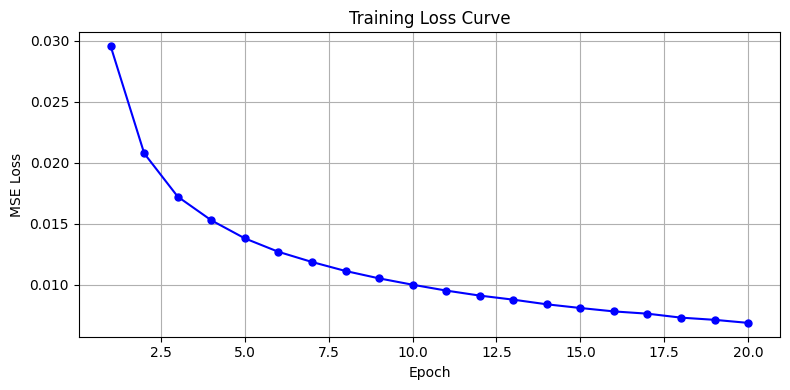

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), loss_history, 'b-o', markersize=5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
_,_,_,_,_,A3t = forward_pass(X_test, W1,b1,W2,b2,W3,b3)
preds = np.argmax(A3t, axis=1)
acc   = np.mean(preds == Y_test) * 100
print(f"✅ Test Accuracy: {acc:.2f}%")


✅ Test Accuracy: 95.54%


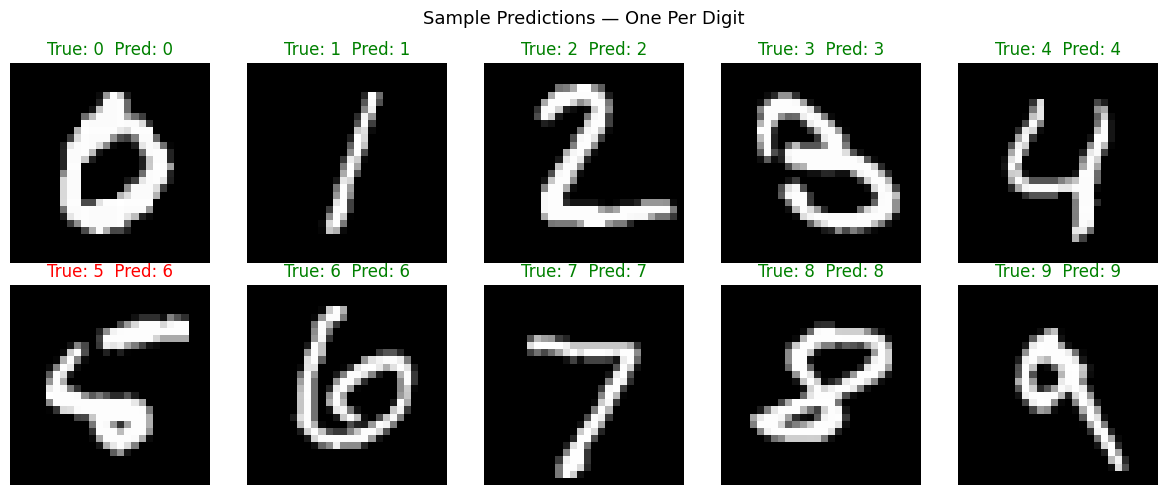

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    idx   = np.where(Y_test == digit)[0][0]
    image = X_test[idx].reshape(28, 28)
    pred  = preds[idx]

    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(
        f"True: {digit}  Pred: {pred}",
        color='green' if pred==digit else 'red'
    )
    axes[digit].axis('off')

plt.suptitle('Sample Predictions — One Per Digit', fontsize=13)
plt.tight_layout()
plt.show()